In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

In [4]:
df = pd.read_csv('train.csv')
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (466, 11)
Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,68,Female,0.6,0.1,1620,95,127,4.6,2.1,0.8,1
1,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.0,1
2,28,Male,0.8,0.3,190,20,14,4.1,2.4,1.4,1
3,60,Male,2.3,0.6,272,79,51,6.6,3.5,1.1,1
4,48,Female,0.9,0.2,173,26,27,6.2,3.1,1.0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         466 non-null    int64  
 1   Gender                      466 non-null    str    
 2   Total_Bilirubin             466 non-null    float64
 3   Direct_Bilirubin            466 non-null    float64
 4   Alkaline_Phosphotase        466 non-null    int64  
 5   Alamine_Aminotransferase    466 non-null    int64  
 6   Aspartate_Aminotransferase  466 non-null    int64  
 7   Total_Protiens              466 non-null    float64
 8   Albumin                     466 non-null    float64
 9   Albumin_and_Globulin_Ratio  464 non-null    float64
 10  Dataset                     466 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 40.2 KB


In [6]:
df.describe().T.style.background_gradient(cmap='coolwarm', axis=0)

,count,mean,std,min,25%,50%,75%,max
Age,466.000000,44.212446,15.650069,4.000000,32.250000,45.000000,56.000000,85.000000
Total_Bilirubin,466.000000,3.318455,6.335770,0.400000,0.800000,1.000000,2.675000,75.000000
Direct_Bilirubin,466.000000,1.472532,2.774472,0.100000,0.200000,0.300000,1.300000,19.700000
Alkaline_Phosphotase,466.000000,289.995708,245.212815,63.000000,174.000000,206.000000,298.000000,2110.000000
Alamine_Aminotransferase,466.000000,84.251073,196.869782,10.000000,24.000000,36.000000,62.000000,2000.000000
Aspartate_Aminotransferase,466.000000,116.491416,314.013021,11.000000,26.000000,43.000000,88.000000,4929.000000
Total_Protiens,466.000000,6.503004,1.087422,2.700000,5.800000,6.600000,7.200000,9.600000
Albumin,466.000000,3.160300,0.793272,0.900000,2.600000,3.100000,3.800000,5.500000
Albumin_and_Globulin_Ratio,464.000000,0.958233,0.326167,0.300000,0.730000,1.000000,1.100000,2.800000
Dataset,466.000000,1.293991,0.456078,1.000000,1.000000,1.000000,2.000000,2.000000


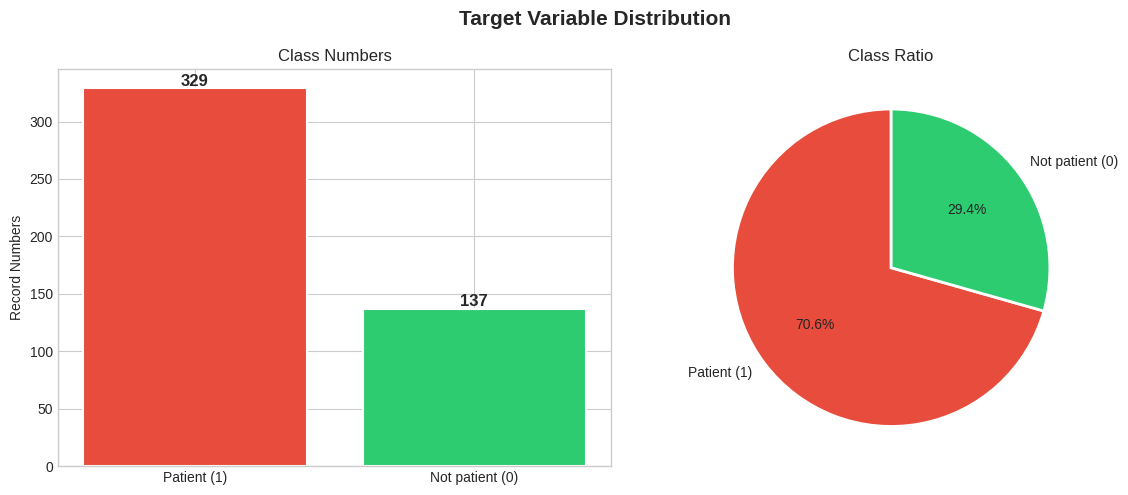

Imbalance Ratio → Patient:Not patient = 2.40:1
   Patient (1): 329 | Not patient (0): 137


In [7]:
df['Dataset'] = df['Dataset'].map({1: 1, 2: 0})

counts = df['Dataset'].value_counts()
labels = ['Patient (1)', 'Not patient (0)']
colors = ['#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')

# Bar plot
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Numbers')
axes[0].set_ylabel('Record Numbers')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold', fontsize=12)

# Pie
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Ratio')

plt.tight_layout()
plt.show()

imbalance_ratio = counts[1] / counts[0]
print(f'Imbalance Ratio → Patient:Not patient = {imbalance_ratio:.2f}:1')
print(f'   Patient (1): {counts[1]} | Not patient (0): {counts[0]}')

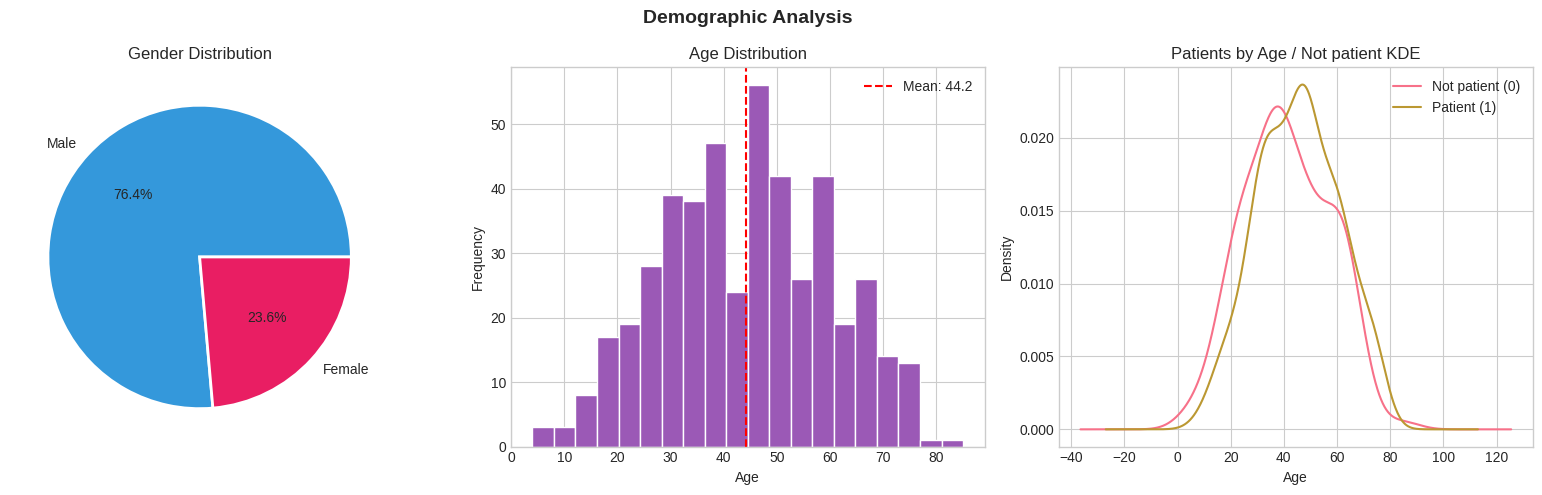

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demographic Analysis', fontsize=14, fontweight='bold')

# Gender Distribution
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e91e63'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Gender Distribution')

# Age histogram
axes[1].hist(df['Age'], bins=20, color='#9b59b6', edgecolor='white', linewidth=1)
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[1].legend()

# Age and Target
df.groupby('Dataset')['Age'].plot(kind='kde', ax=axes[2], legend=True)
axes[2].set_title('Patients by Age / Not patient KDE')
axes[2].set_xlabel('Age')
axes[2].legend(['Not patient (0)', 'Patient (1)'])

plt.tight_layout()
plt.show()

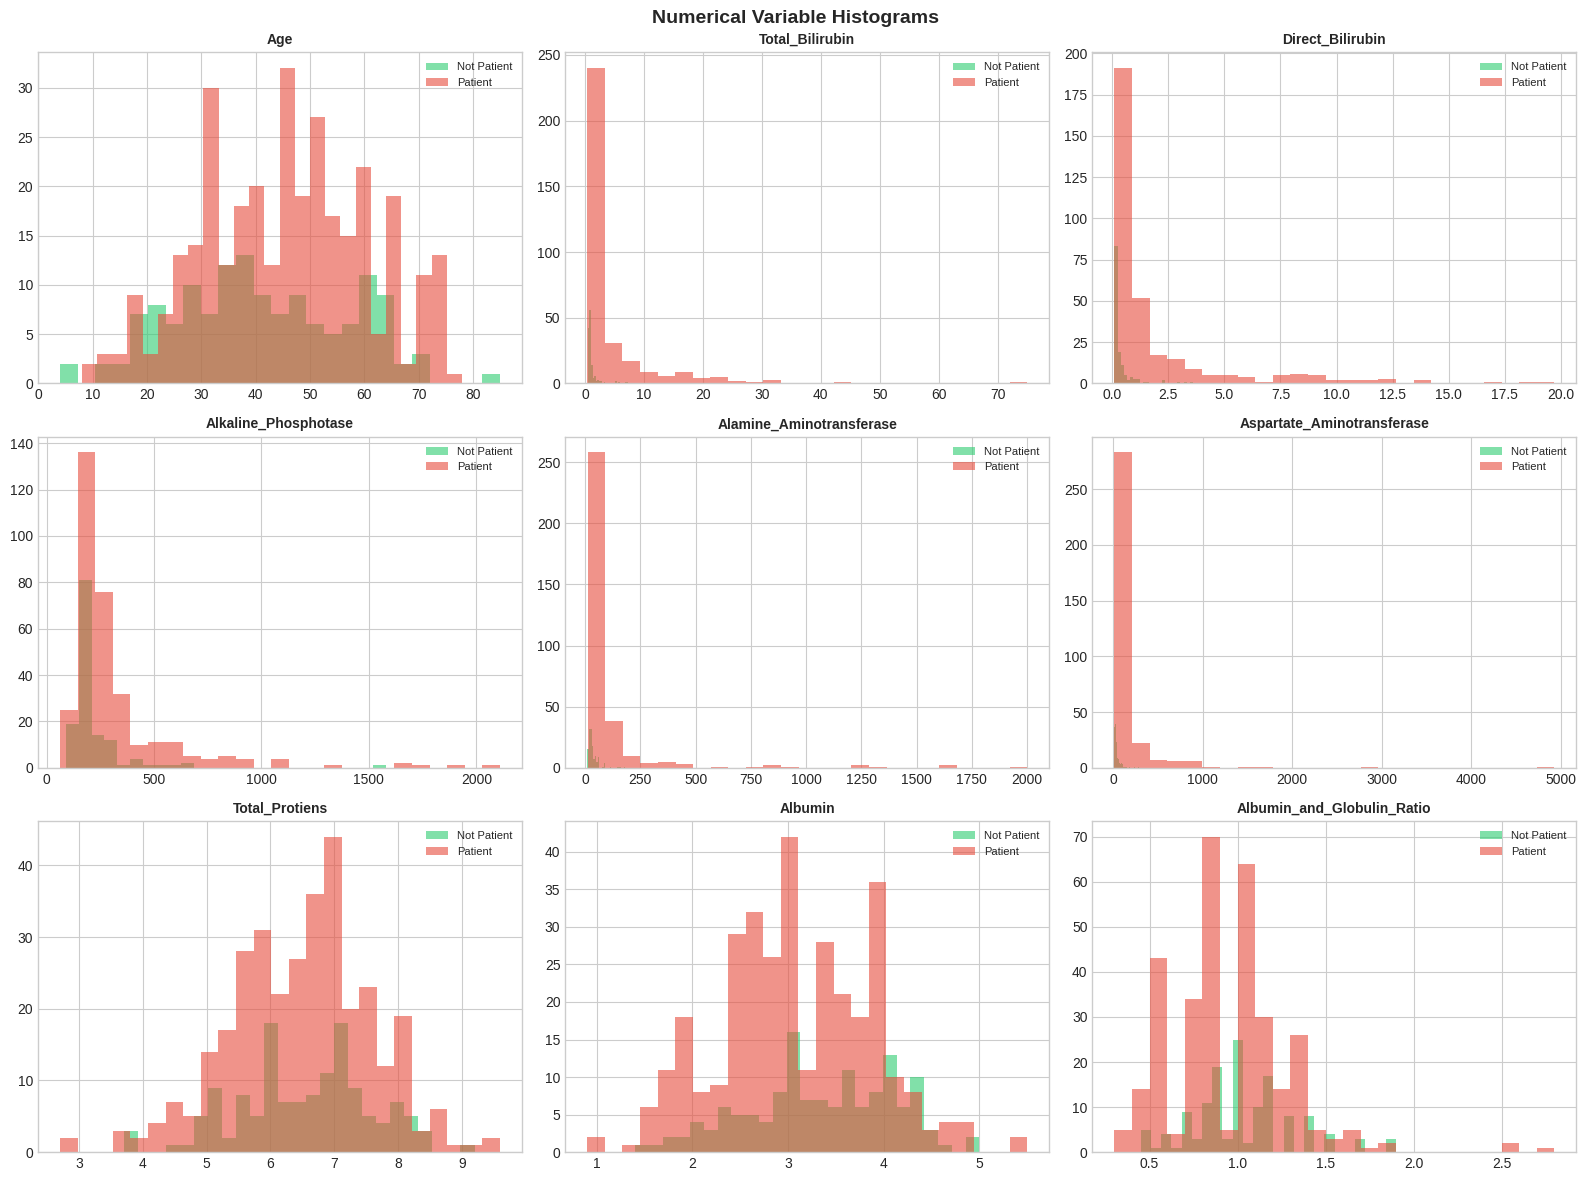

In [11]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ['Dataset']]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Numerical Variable Histograms', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        subset = df[df['Dataset'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='Not Patient' if label == 0 else 'Patient', edgecolor='none')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

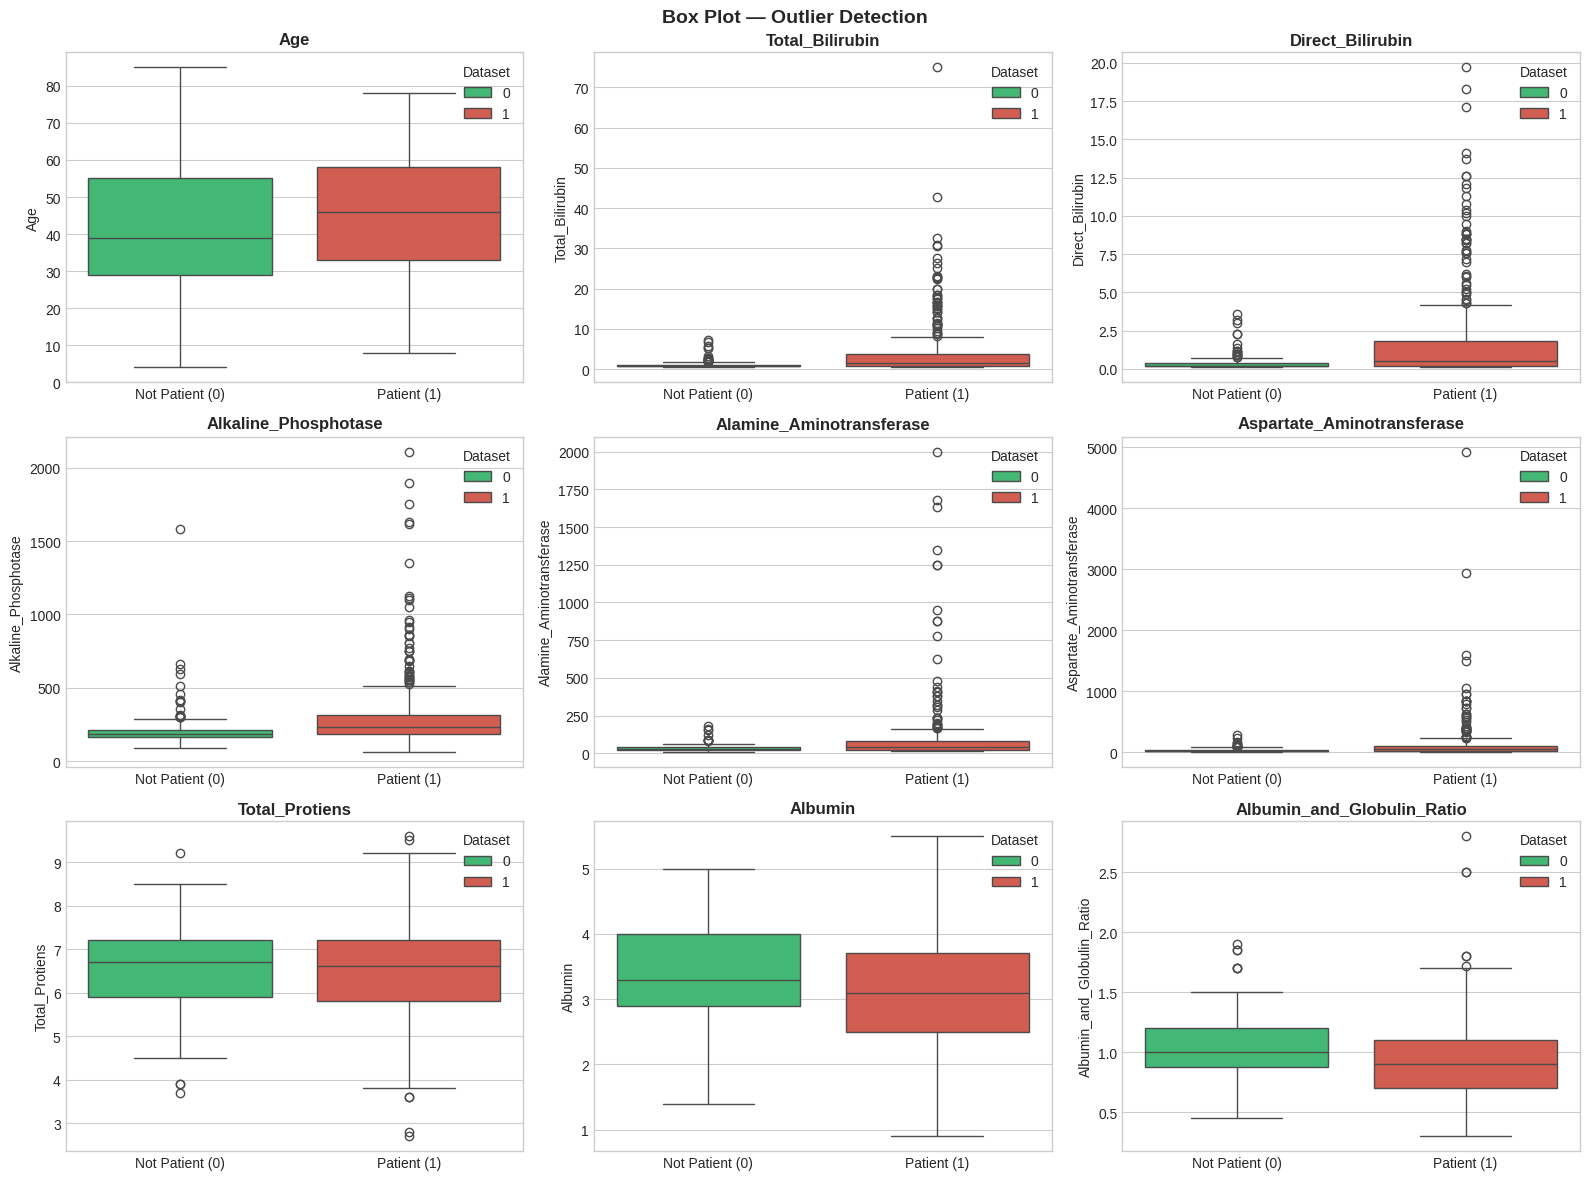

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Box Plot — Outlier Detection', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    sns.boxplot(x='Dataset', y=col, data=df, ax=ax,
                hue='Dataset',
                palette={0: '#2ecc71', 1: '#e74c3c'})
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels(['Not Patient (0)', 'Patient (1)'])
    ax.set_xlabel('')

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

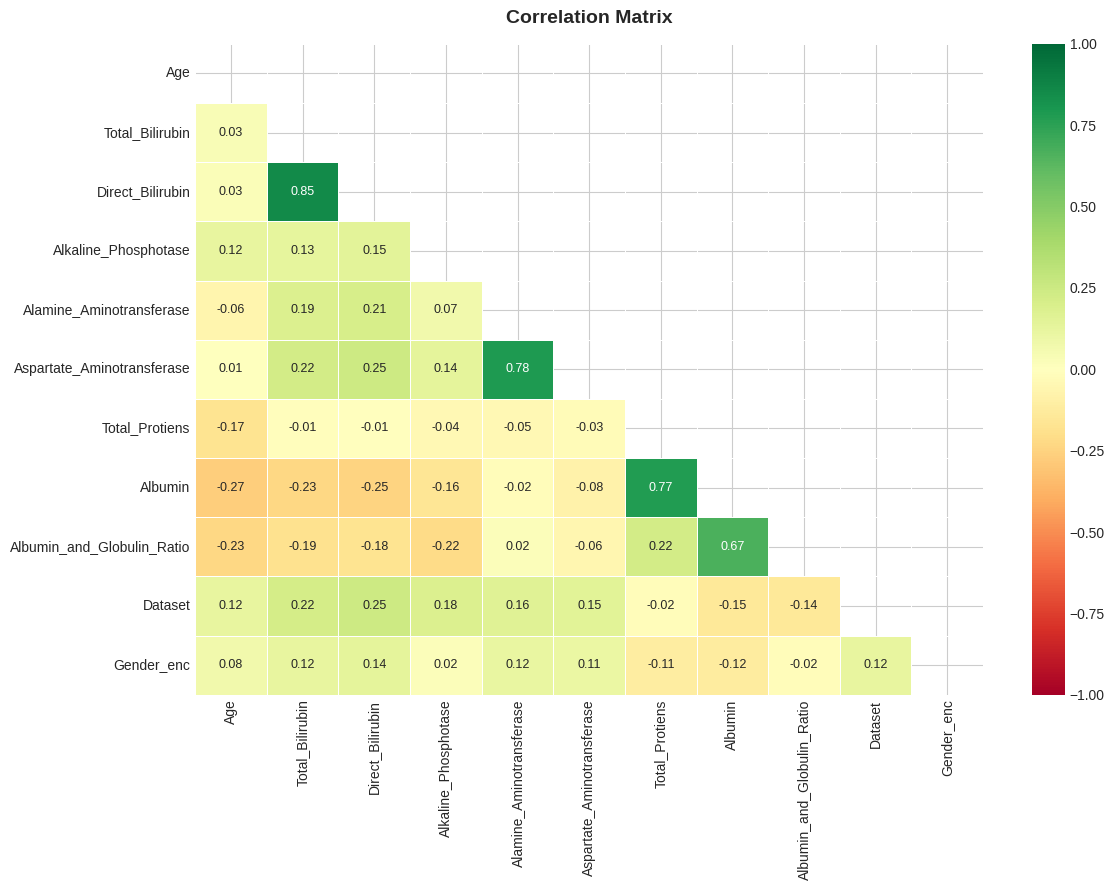


Correlation with the Target Variable:
Direct_Bilirubin              0.245304
Total_Bilirubin               0.216667
Alkaline_Phosphotase          0.181668
Alamine_Aminotransferase      0.159046
Aspartate_Aminotransferase    0.150302
Albumin                       0.147050
Albumin_and_Globulin_Ratio    0.141255
Age                           0.123261
Gender_enc                    0.118250
Total_Protiens                0.018162
Name: Dataset, dtype: float64


In [14]:
df_temp = df.copy()
df_temp['Gender_enc'] = LabelEncoder().fit_transform(df_temp['Gender'])
df_temp.drop(columns=['Gender'], inplace=True)
corr = df_temp.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

target_corr = corr['Dataset'].drop('Dataset').abs().sort_values(ascending=False)
print('\nCorrelation with the Target Variable:')
print(target_corr)

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if missing_df.empty:
    print('There is no missing values')
else:
    print(missing_df)
    for col in missing_df.index:
        df[col].fillna(df[col].median(), inplace=True)
    print('Missing values ​​were filled in with the median.')

print(f'\nshape: {df.shape}')

                            Missing  Percentage (%)
Albumin_and_Globulin_Ratio        2            0.43
Missing values ​​were filled in with the median.

shape: (466, 11)


In [ ]:
df_clean = df.copy()
outlier_summary = {}

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR  
    upper = Q3 + 3.0 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before - len(df_clean)
    if removed > 0:
        outlier_summary[col] = removed

print(f'Before outlier cleaning: {df.shape[0]} row')
print(f'After outlier cleaning: {df_clean.shape[0]} row')
print(f'Number of rows extracted per column: {outlier_summary}')

df = df_clean.copy()
print(f'\nCleaned Data: {df.shape}')

Before outlier cleaning: 466 satır
After outlier cleaning: 342 satır
Number of rows extracted per column: {'Total_Bilirubin': 44, 'Direct_Bilirubin': 21, 'Alkaline_Phosphotase': 19, 'Alamine_Aminotransferase': 24, 'Aspartate_Aminotransferase': 14, 'Albumin_and_Globulin_Ratio': 2}

Cleaned Data: (342, 11)


In [17]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])  # Male→1, Female→0

X = df.drop(columns=['Dataset'])
y = df['Dataset']

print(f'Feature shape: {X.shape}')
print(f'Label distribution:\n{y.value_counts()}')

Feature shape: (342, 10)
Label distribution:
Dataset
1    212
0    130
Name: count, dtype: int64


before SMOTE:
Dataset
1    212
0    130
Name: count, dtype: int64

after SMOTE:
Dataset
1    212
0    212
Name: count, dtype: int64


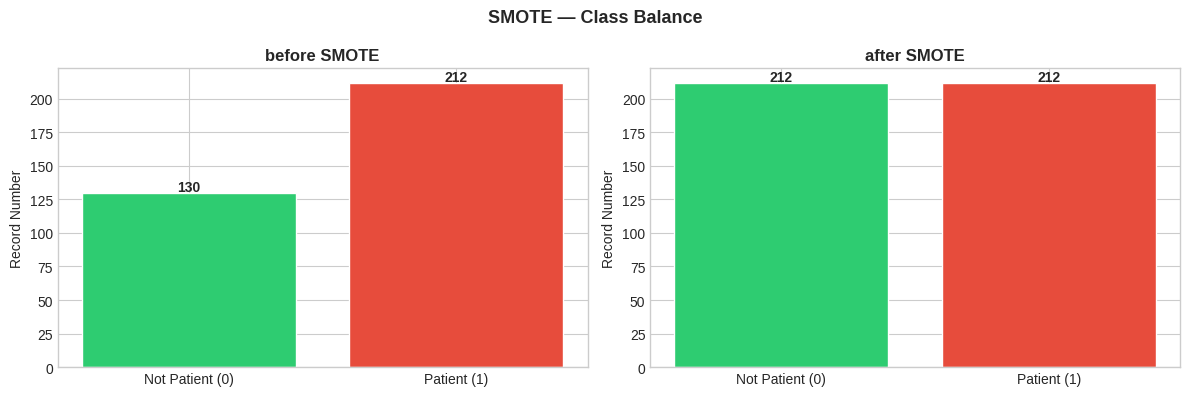

In [18]:
print('before SMOTE:')
print(y.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('\nafter SMOTE:')
print(pd.Series(y_resampled).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SMOTE — Class Balance', fontsize=13, fontweight='bold')

for ax, counts, title in zip(
    axes,
    [y.value_counts(), pd.Series(y_resampled).value_counts()],
    ['before SMOTE', 'after SMOTE']
):
    bars = ax.bar(['Not Patient (0)', 'Patient (1)'],
                  [counts.get(0, 0), counts.get(1, 0)],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Record Number')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_resampled
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (339, 10) | Test: (85, 10)


In [20]:
models = {
    'Logistic Regression'       : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'             : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'             : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Extra Trees'               : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting'         : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'AdaBoost'                  : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost'                   : XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'SVM'                       : SVC(probability=True, random_state=RANDOM_STATE),
    'KNN'                       : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'               : GaussianNB(),
}

print(f'{len(models)} model is ready.')

10 model is ready.


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_prob  = model.predict_proba(X_test_sc)[:, 1]
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1')

    results.append({
        'Model'       : name,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1-Score'    : f1_score(y_test, y_pred),
        'ROC-AUC'     : roc_auc_score(y_test, y_prob),
        'CV F1 Mean'  : cv_scores.mean(),
        'CV F1 Std'   : cv_scores.std(),
    })
    trained_models[name] = (model, y_pred, y_prob)
    print(f'✔ {name:25s} | ACC: {accuracy_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}')

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\nThe Models were ranked according to their F1-Score.')

✔ Logistic Regression       | ACC: 0.6471 | F1: 0.6250 | AUC: 0.6417
✔ Decision Tree             | ACC: 0.5647 | F1: 0.5647 | AUC: 0.5648
✔ Random Forest             | ACC: 0.7176 | F1: 0.7333 | AUC: 0.7470
✔ Extra Trees               | ACC: 0.7176 | F1: 0.7333 | AUC: 0.7597
✔ Gradient Boosting         | ACC: 0.6000 | F1: 0.6136 | AUC: 0.6406
✔ AdaBoost                  | ACC: 0.6235 | F1: 0.6098 | AUC: 0.6924
✔ XGBoost                   | ACC: 0.6588 | F1: 0.6588 | AUC: 0.7038
✔ SVM                       | ACC: 0.5647 | F1: 0.5067 | AUC: 0.6556
✔ KNN                       | ACC: 0.6706 | F1: 0.6500 | AUC: 0.7046
✔ Naive Bayes               | ACC: 0.5647 | F1: 0.4638 | AUC: 0.6329

The Models were ranked according to their F1-Score.


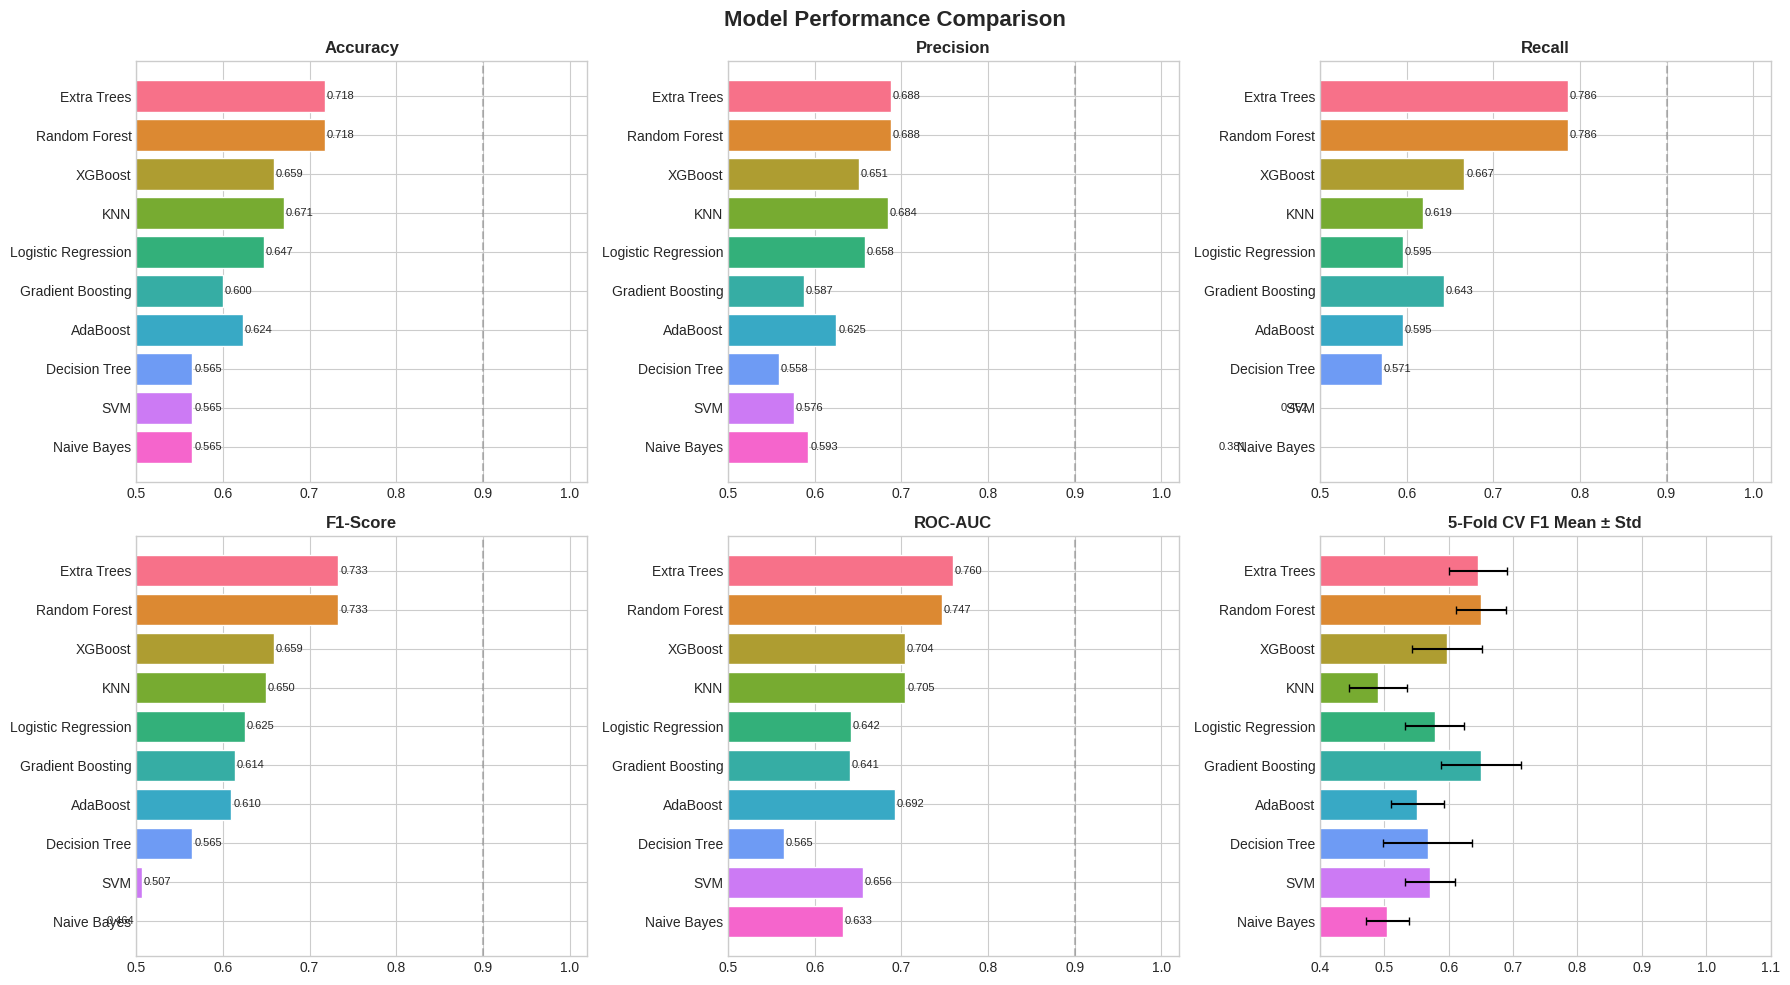

In [23]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = results_df['Model'].tolist()
colors = sns.color_palette('husl', len(model_names))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    vals = results_df[metric].values
    bars = ax.barh(model_names[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlim(0.5, 1.02)
    ax.axvline(0.9, color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

# CV F1 Mean ± Std
ax = axes_flat[5]
ax.barh(model_names[::-1], results_df['CV F1 Mean'].values[::-1],
        xerr=results_df['CV F1 Std'].values[::-1],
        color=colors[::-1], edgecolor='white', capsize=3)
ax.set_title('5-Fold CV F1 Mean ± Std', fontweight='bold', fontsize=12)
ax.set_xlim(0.4, 1.1)

plt.tight_layout()
plt.show()

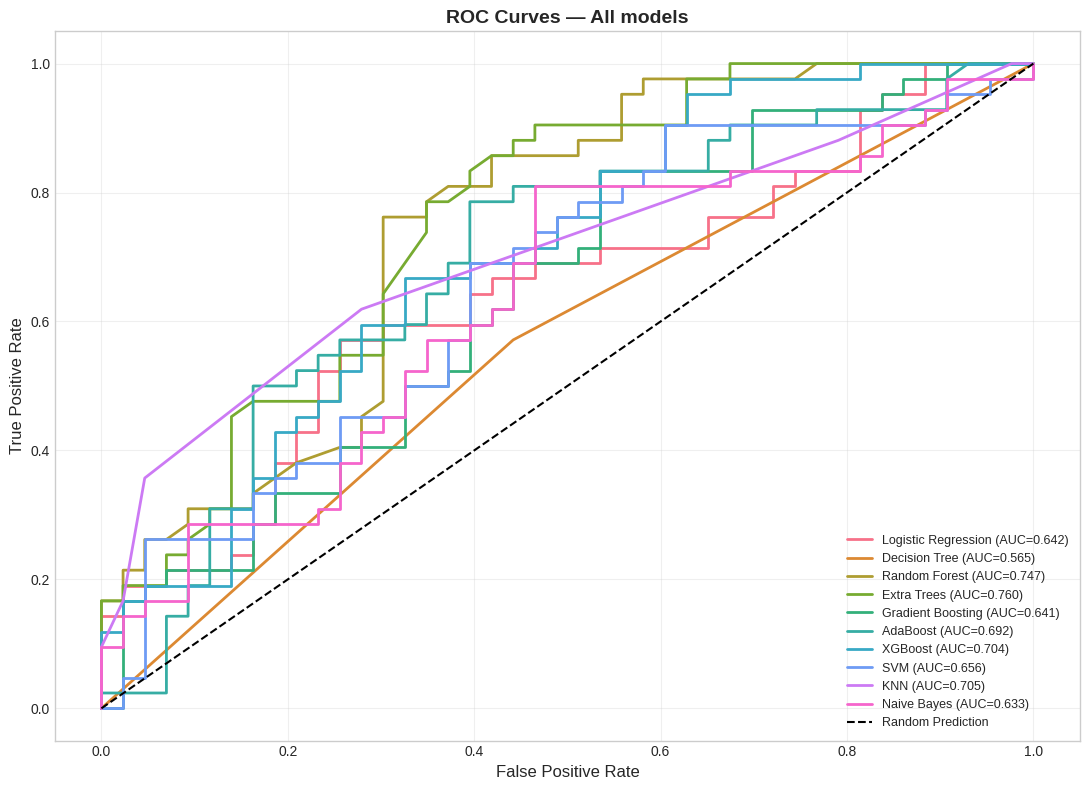

In [24]:
plt.figure(figsize=(11, 8))
palette = sns.color_palette('husl', len(models))

for i, (name, (model, y_pred, y_prob)) in enumerate(trained_models.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=palette[i], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Prediction')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
best_name = results_df.iloc[0]['Model']
best_model, best_pred, best_prob = trained_models[best_name]

print(f'The best model: {best_name}')
print(f'   F1-Score : {results_df.iloc[0]["F1-Score"]:.4f}')
print(f'   ROC-AUC  : {results_df.iloc[0]["ROC-AUC"]:.4f}')
print(f'   Accuracy : {results_df.iloc[0]["Accuracy"]:.4f}')
print()
print(classification_report(y_test, best_pred, target_names=['Not patient (0)', 'Patient (1)']))

The best model: Extra Trees
   F1-Score : 0.7333
   ROC-AUC  : 0.7597
   Accuracy : 0.7176

                 precision    recall  f1-score   support

Not patient (0)       0.76      0.65      0.70        43
    Patient (1)       0.69      0.79      0.73        42

       accuracy                           0.72        85
      macro avg       0.72      0.72      0.72        85
   weighted avg       0.72      0.72      0.72        85



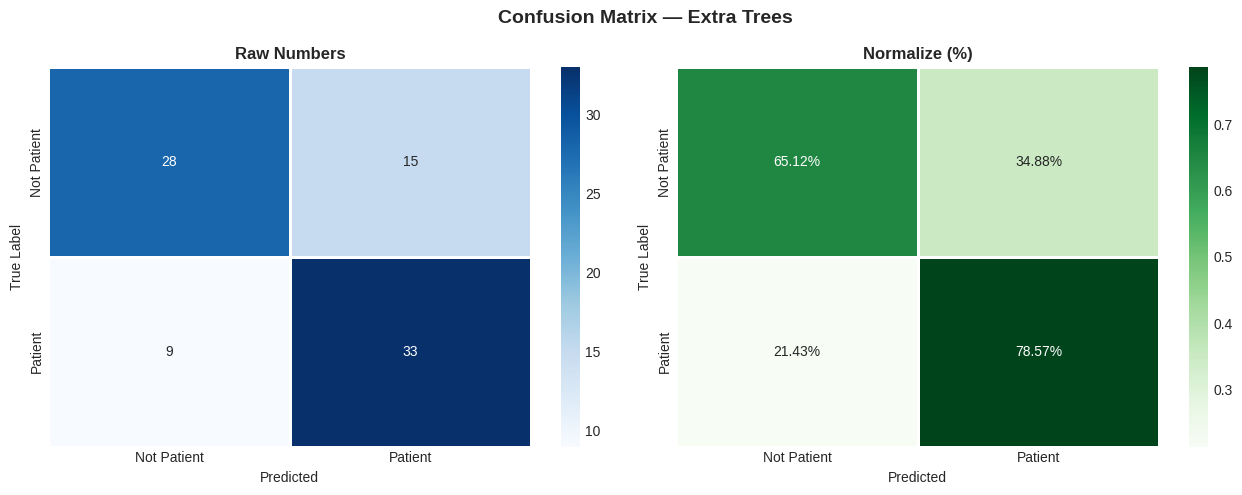

In [26]:
cm = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Patient', 'Patient'],
            yticklabels=['Not Patient', 'Patient'],
            linewidths=1, linecolor='white')
axes[0].set_title('Raw Numbers', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted')

# Normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Not Patient', 'Patient'],
            yticklabels=['Not Patient', 'Patient'],
            linewidths=1, linecolor='white')
axes[1].set_title('Normalize (%)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

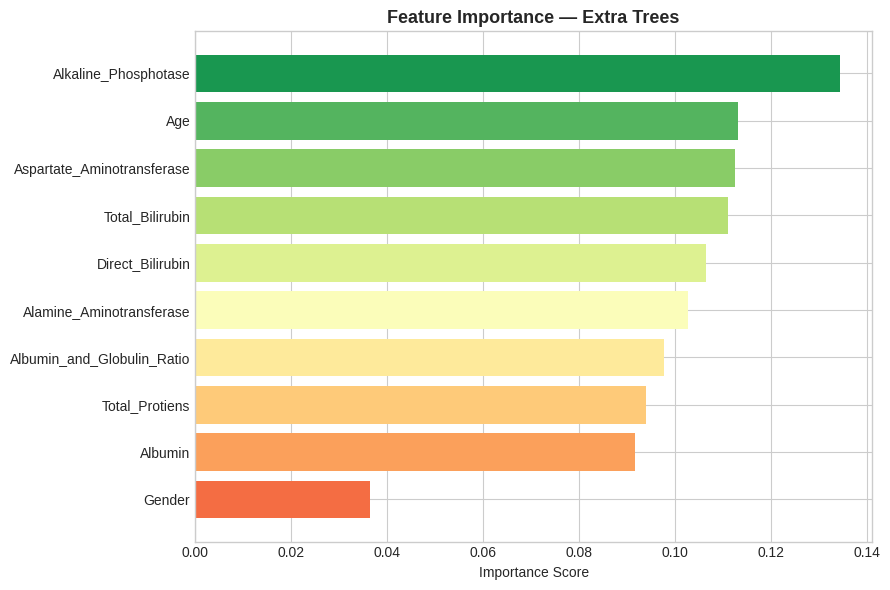

In [27]:
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    plt.figure(figsize=(9, 6))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
    plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi)
    plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance is not directly available for this model.')

In [28]:
joblib.dump(best_model, 'best_liver_model.joblib')
joblib.dump(scaler,     'liver_scaler.joblib')

print(f'The Model Saved: best_liver_model.joblib  ({best_name})')
print(f'The Scaler Saved: liver_scaler.joblib')

The Model Saved: best_liver_model.joblib  (Extra Trees)
The Scaler Saved: liver_scaler.joblib


In [30]:
best_row = results_df.iloc[0]
print('=' * 60)
print('                   SUMMARY')
print('=' * 60)
print(f'  Total Data (after cleaning) : {df.shape[0]} row')
print(f'  Balancing Method               : SMOTE')
print(f'  After Balancing                : {len(y_resampled)} row')
print(f'  Test Ratio                     : %20')
print(f'  Cross Validation               : 5-Fold Stratified')
print(f'  Number of Models Tested        : {len(models)}')
print('-' * 60)
print(f'     The Best Model              : {best_row["Model"]}')
print(f'     Accuracy                    : {best_row["Accuracy"]:.4f}')
print(f'     Precision                   : {best_row["Precision"]:.4f}')
print(f'     Recall                      : {best_row["Recall"]:.4f}')
print(f'     F1-Score                    : {best_row["F1-Score"]:.4f}')
print(f'     ROC-AUC                     : {best_row["ROC-AUC"]:.4f}')
print(f'     CV F1 (5-Fold)              : {best_row["CV F1 Mean"]:.4f} ± {best_row["CV F1 Std"]:.4f}')
print('=' * 60)

                   SUMMARY
  Total Data (after cleaning) : 342 row
  Balancing Method               : SMOTE
  After Balancing                : 424 row
  Test Ratio                     : %20
  Cross Validation               : 5-Fold Stratified
  Number of Models Tested        : 10
------------------------------------------------------------
     The Best Model              : Extra Trees
     Accuracy                    : 0.7176
     Precision                   : 0.6875
     Recall                      : 0.7857
     F1-Score                    : 0.7333
     ROC-AUC                     : 0.7597
     CV F1 (5-Fold)              : 0.6460 ± 0.0452
